# ¿Qué diferencia a los compuestos activos en falcipaína-2 que NO se traducen en actividad frente a *P. falciparum*?

**Dataset:** 65 compuestos, todos activos en la enzima (`Label_FP2 = 1`).
- `Label_PF = 1` (n=51) → la actividad enzimática **SÍ** se traduce en actividad fenotípica (organismo completo)
- `Label_PF = 0` (n=14) → la actividad enzimática **NO** se traduce en actividad fenotípica

## Estrategia
1. **Descriptores moleculares**: MACCS keys (167 bits, subestructuras), Mordred 2D
   (~1600 descriptores fisicoquímicos/topológicos) y un set de descriptores de
   permeabilidad calculados a mano (MW, LogP, TPSA, HBD/HBA, rotables...).
2. **Limpieza**: fuera varianza casi nula, exceso de NaN y descriptores redundantes (r>0.95).
3. **Exploración no supervisada** (lo que sugirió tu compañero): PCA y t-SNE/UMAP —
   útiles para ver si hay separación, pero **no** para saber qué la causa.
4. **Estadística univariante** (la pieza que falta si solo se hace PCA/t-SNE):
   Mann-Whitney U (continuos) y Fisher exacto (MACCS), con corrección FDR y tamaño de efecto.
5. **Modelo regularizado (Lasso + Leave-One-Out CV)**: solo como triangulación adicional
   para ver qué descriptores sobreviven de forma consistente, nunca como "modelo predictivo".
6. **Chequeo de confusor**: ¿es simplemente que los PF=0 son menos potentes en la propia
   enzima? Si no se controla esto, se puede confundir "problema de permeabilidad" con
   "compuestos peor optimizados en general".
7. **Síntesis final**: descriptores respaldados por ≥2 de las 3 fuentes de evidencia.
```

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, RDLogger
from rdkit.Chem import MACCSkeys, Descriptors, Crippen, rdMolDescriptors

from scipy.stats import mannwhitneyu, fisher_exact, pointbiserialr, spearmanr
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# --- Parámetros que puedes tocar ---
INPUT_CSV = "compuestos_solapados.csv"   # <- cambia esto si tu archivo se llama distinto
OUTDIR = Path("resultados")
OUTDIR.mkdir(exist_ok=True)

SMILES_COL = "smiles_std"
LABEL_COL = "Label_PF"          # 1 = traduce a fenotipo, 0 = no traduce
ENZ_LABEL_COL = "Label_FP2"     # debería ser 1 en todo el dataset (control)

RANDOM_STATE = 42
FDR_ALPHA = 0.10   # con n=65 usamos un FDR algo más laxo que 0.05; se reporta también el p sin corregir
CORR_THRESHOLD = 0.95

## 1. Carga y validación de los datos

In [3]:
def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {SMILES_COL, LABEL_COL, ENZ_LABEL_COL}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas en el CSV: {missing}")

    if not (df[ENZ_LABEL_COL] == 1).all():
        n_bad = (df[ENZ_LABEL_COL] != 1).sum()
        warnings.warn(
            f"{n_bad} filas tienen {ENZ_LABEL_COL} != 1. Este análisis asume que "
            "TODAS las filas son activos de enzima; se filtran las que no lo sean."
        )
        df = df[df[ENZ_LABEL_COL] == 1].reset_index(drop=True)

    mols = [Chem.MolFromSmiles(s) for s in df[SMILES_COL]]
    bad = [i for i, m in enumerate(mols) if m is None]
    if bad:
        warnings.warn(f"{len(bad)} SMILES no se pudieron parsear y se eliminan: {bad}")
    df["_mol"] = mols
    df = df[df["_mol"].notna()].reset_index(drop=True)

    print(f"[OK] {len(df)} compuestos cargados. "
          f"Label_PF=1 (traduce a fenotipo): {(df[LABEL_COL]==1).sum()} | "
          f"Label_PF=0 (no traduce): {(df[LABEL_COL]==0).sum()}")
    return df


df = load_data(INPUT_CSV)
labels = df[LABEL_COL]

[OK] 65 compuestos cargados. Label_PF=1 (traduce a fenotipo): 51 | Label_PF=0 (no traduce): 14


## 2. Cálculo de descriptores: MACCS, Mordred 2D y fisicoquímicos

In [4]:
def compute_maccs(mols) -> pd.DataFrame:
    """167 bits (bit 0 no se usa en RDKit, se descarta)."""
    fps = [MACCSkeys.GenMACCSKeys(m) for m in mols]
    arr = np.array([list(fp.ToBitString()) for fp in fps]).astype(int)
    cols = [f"MACCS_{i}" for i in range(arr.shape[1])]
    maccs_df = pd.DataFrame(arr, columns=cols)
    return maccs_df.drop(columns=["MACCS_0"])


def compute_permeability_descriptors(mols) -> pd.DataFrame:
    """Descriptores fisicoquímicos clásicos ligados a permeabilidad/eflujo."""
    rows = []
    for m in mols:
        rows.append({
            "MolWt": Descriptors.MolWt(m),
            "MolLogP": Crippen.MolLogP(m),
            "TPSA": rdMolDescriptors.CalcTPSA(m),
            "NumHBD": rdMolDescriptors.CalcNumHBD(m),
            "NumHBA": rdMolDescriptors.CalcNumHBA(m),
            "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(m),
            "FormalCharge": Chem.GetFormalCharge(m),
            "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(m),
            "NumRings": rdMolDescriptors.CalcNumRings(m),
            "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(m),
            "NumHeavyAtoms": m.GetNumHeavyAtoms(),
            "NumBasicN": sum(1 for a in m.GetAtoms()
                              if a.GetSymbol() == "N" and a.GetFormalCharge() >= 0
                              and a.GetTotalNumHs() > 0),
        })
    return pd.DataFrame(rows)


def compute_mordred(mols) -> pd.DataFrame:
    """Descriptores Mordred 2D. Si Mordred no está instalado, se sigue sin ellos."""
    try:
        from mordred import Calculator, descriptors
    except ImportError:
        warnings.warn("Mordred no está instalado; se continúa sin sus descriptores "
                       "(pip install mordred).")
        return pd.DataFrame(index=range(len(mols)))
    calc = Calculator(descriptors, ignore_3D=True)
    result = calc.pandas(mols, quiet=True)
    return result.apply(pd.to_numeric, errors="coerce").reset_index(drop=True)


mols = df["_mol"].tolist()
print("[*] Calculando MACCS keys...")
maccs_df = compute_maccs(mols)
print("[*] Calculando descriptores de permeabilidad...")
perm_df = compute_permeability_descriptors(mols)
print("[*] Calculando descriptores Mordred 2D (puede tardar)...")
mordred_df = compute_mordred(mols)

continuous_df = pd.concat([perm_df, mordred_df], axis=1)
continuous_df = continuous_df.loc[:, ~continuous_df.columns.duplicated()]
binary_df = maccs_df

print(f"[OK] Descriptores continuos: {continuous_df.shape[1]} | MACCS: {binary_df.shape[1]}")

[*] Calculando MACCS keys...
[*] Calculando descriptores de permeabilidad...
[*] Calculando descriptores Mordred 2D (puede tardar)...
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\angel\miniconda3\envs\tfm\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
[OK] Descriptores continuos: 1625 | MACCS: 166


## 3. Limpieza de descriptores

In [5]:
def clean_continuous(continuous_df: pd.DataFrame, max_na_frac=0.2) -> pd.DataFrame:
    d = continuous_df.copy()
    d = d.loc[:, d.isna().mean() <= max_na_frac]
    d = d.fillna(d.median(numeric_only=True))
    variances = d.var(numeric_only=True)
    d = d.loc[:, variances[variances > 1e-8].index]
    corr = d.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > CORR_THRESHOLD)]
    d = d.drop(columns=to_drop)
    print(f"[OK] Descriptores continuos tras limpieza: {d.shape[1]} "
          f"(descartados {continuous_df.shape[1] - d.shape[1]})")
    return d


def clean_binary(binary_df: pd.DataFrame, min_count=3) -> pd.DataFrame:
    """Descartamos bits MACCS (casi) siempre 0 o siempre 1: con n=65 no aportan poder
    estadístico y solo añaden ruido a la corrección FDR."""
    counts = binary_df.sum(axis=0)
    keep = counts[(counts >= min_count) & (counts <= len(binary_df) - min_count)].index
    d = binary_df[keep]
    print(f"[OK] MACCS keys tras limpieza: {d.shape[1]} "
          f"(descartados {binary_df.shape[1] - d.shape[1]})")
    return d


continuous_clean = clean_continuous(continuous_df)
binary_clean = clean_binary(binary_df)

[OK] Descriptores continuos tras limpieza: 493 (descartados 1132)
[OK] MACCS keys tras limpieza: 115 (descartados 51)


## 4. PCA

Reducción de dimensionalidad sobre los descriptores continuos escalados. Miramos si
`Label_PF` separa en el espacio de componentes principales, y qué componente correlaciona
más con el label (no siempre es PC1).

PC1=26.9% var, PC2=11.3% var (acumulado 2 PC: 38.2%)


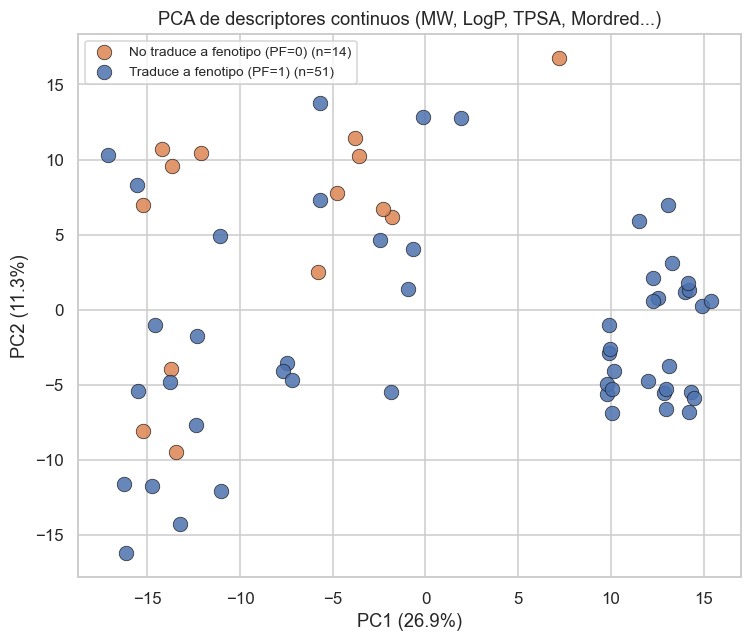

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(continuous_clean)

n_comp = min(10, X_scaled.shape[0] - 1, X_scaled.shape[1])
pca = PCA(n_components=n_comp, random_state=RANDOM_STATE)
scores = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_

print(f"PC1={var_exp[0]*100:.1f}% var, PC2={var_exp[1]*100:.1f}% var "
      f"(acumulado 2 PC: {sum(var_exp[:2])*100:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 6))
palette = {0: "#DD8452", 1: "#4C72B0"}
names = {0: "No traduce a fenotipo (PF=0)", 1: "Traduce a fenotipo (PF=1)"}
for lab in [0, 1]:
    mask = labels.values == lab
    ax.scatter(scores[mask, 0], scores[mask, 1], s=90, alpha=0.85, c=palette[lab],
               label=f"{names[lab]} (n={mask.sum()})", edgecolor="k", linewidth=0.5)
ax.set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
ax.set_title("PCA de descriptores continuos (MW, LogP, TPSA, Mordred...)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUTDIR / "pca_scatter.png", dpi=150)
plt.show()

In [7]:
# ¿Qué componente principal separa mejor los dos grupos?
pc_corrs = []
for i in range(n_comp):
    r, p = pointbiserialr(labels.values, scores[:, i])
    pc_corrs.append((f"PC{i+1}", r, p, var_exp[i]))
pc_corr_df = pd.DataFrame(pc_corrs, columns=["PC", "corr_con_label", "p_valor", "var_explicada"])
pc_corr_df = pc_corr_df.reindex(pc_corr_df["corr_con_label"].abs().sort_values(ascending=False).index)
pc_corr_df.to_csv(OUTDIR / "pca_pc_vs_label.csv", index=False)
best_pc_idx = int(pc_corr_df.index[0])
print(f"El PC más asociado al label es {pc_corr_df.iloc[0]['PC']} "
      f"(r={pc_corr_df.iloc[0]['corr_con_label']:.2f}, p={pc_corr_df.iloc[0]['p_valor']:.3f})")
pc_corr_df

El PC más asociado al label es PC2 (r=-0.39, p=0.001)


,PC,corr_con_label,p_valor,var_explicada
1,PC2,-0.389000,0.001362,0.112690
0,PC1,0.365520,0.002753,0.268828
4,PC5,-0.233260,0.061484,0.069676
7,PC8,-0.165359,0.188045,0.037814
3,PC4,-0.152805,0.224290,0.077145
6,PC7,0.113059,0.369876,0.048286
8,PC9,-0.100556,0.425451,0.030809
5,PC6,-0.091118,0.470377,0.050647
2,PC3,-0.045838,0.716921,0.089275
9,PC10,-0.003611,0.977222,0.028138


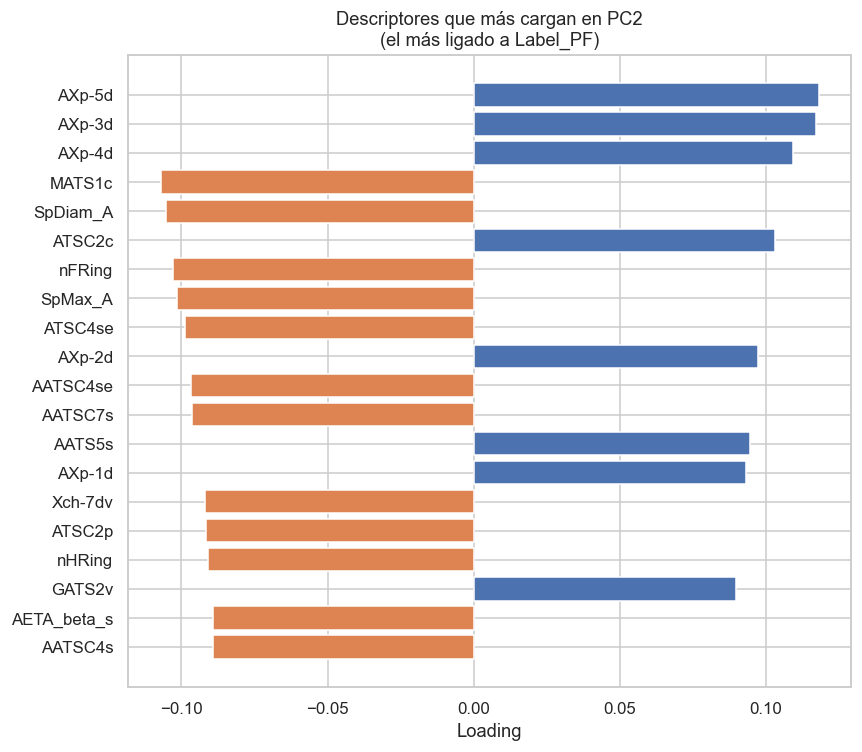

In [8]:
# Loadings del PC más discriminante: qué descriptores lo componen
loadings = pd.Series(pca.components_[best_pc_idx], index=continuous_clean.columns)
top_loadings = loadings.reindex(loadings.abs().sort_values(ascending=False).index).head(20)
top_loadings.to_csv(OUTDIR / f"pca_top_loadings_{pc_corr_df.iloc[0]['PC']}.csv", header=["loading"])

fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#4C72B0" if v > 0 else "#DD8452" for v in top_loadings.values]
ax.barh(top_loadings.index[::-1], top_loadings.values[::-1], color=colors[::-1])
ax.set_xlabel("Loading")
ax.set_title(f"Descriptores que más cargan en {pc_corr_df.iloc[0]['PC']}\n(el más ligado a Label_PF)")
fig.tight_layout()
fig.savefig(OUTDIR / "pca_top_loadings.png", dpi=150)
plt.show()

## 5. t-SNE / UMAP

**Aviso:** con n=65 estos embeddings son solo descriptivos. No interpretes la distancia
entre clusters como una medida cuantitativa fiable — t-SNE distorsiona distancias globales,
y con muestras tan pequeñas la elección de `perplexity` puede cambiar mucho el resultado.

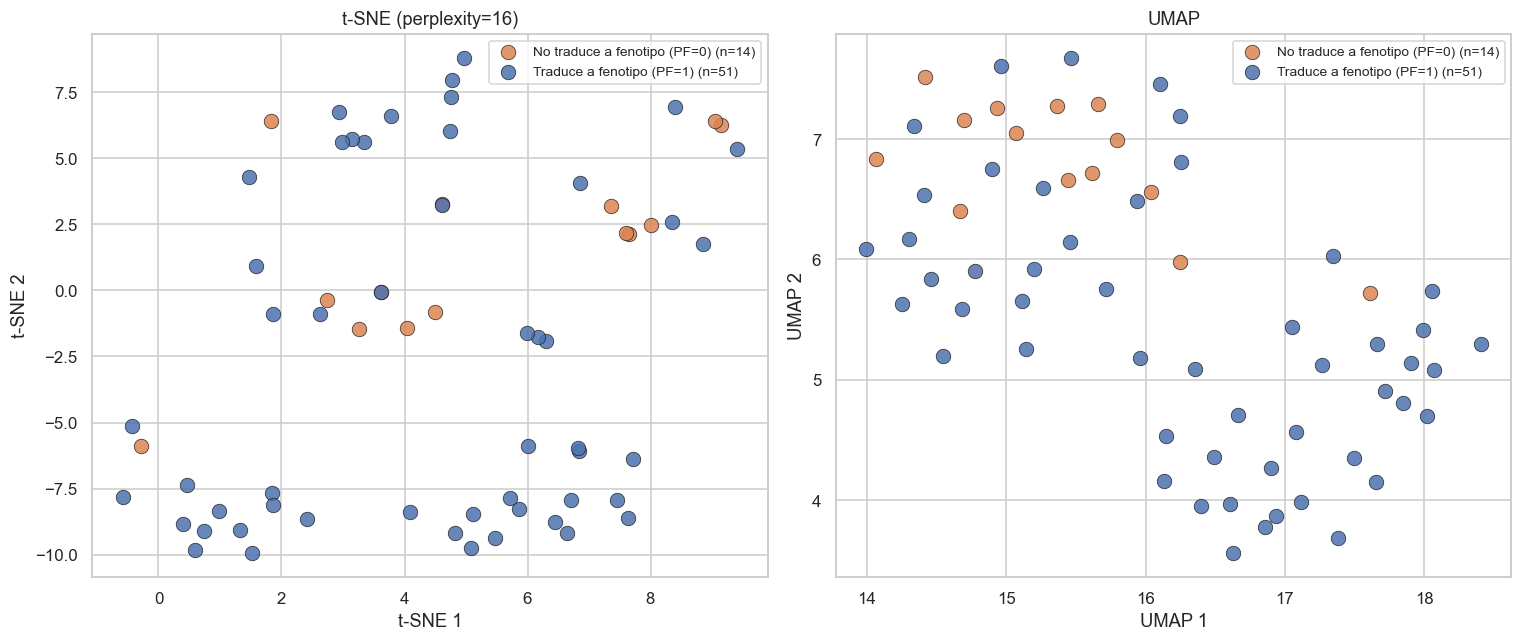

In [9]:
def umap_available():
    try:
        import umap  # noqa
        return True
    except ImportError:
        return False


n = X_scaled.shape[0]
perplexity = max(5, min(30, n // 4))
tsne = TSNE(n_components=2, perplexity=perplexity, random_state=RANDOM_STATE,
            init="pca", learning_rate="auto")
emb_tsne = tsne.fit_transform(X_scaled)

has_umap = umap_available()
fig, axes = plt.subplots(1, 2 if has_umap else 1, figsize=(14 if has_umap else 7, 6))
axes = np.atleast_1d(axes)

for lab in [0, 1]:
    mask = labels.values == lab
    axes[0].scatter(emb_tsne[mask, 0], emb_tsne[mask, 1], s=90, alpha=0.85, c=palette[lab],
                    label=f"{names[lab]} (n={mask.sum()})", edgecolor="k", linewidth=0.5)
axes[0].set_title(f"t-SNE (perplexity={perplexity})")
axes[0].legend(fontsize=9)
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")

if has_umap:
    import umap
    reducer = umap.UMAP(n_neighbors=min(15, n - 1), random_state=RANDOM_STATE)
    emb_umap = reducer.fit_transform(X_scaled)
    for lab in [0, 1]:
        mask = labels.values == lab
        axes[1].scatter(emb_umap[mask, 0], emb_umap[mask, 1], s=90, alpha=0.85, c=palette[lab],
                        label=f"{names[lab]} (n={mask.sum()})", edgecolor="k", linewidth=0.5)
    axes[1].set_title("UMAP")
    axes[1].legend(fontsize=9)
    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")

fig.tight_layout()
fig.savefig(OUTDIR / "tsne_umap_scatter.png", dpi=150)
plt.show()

## 6. Estadística univariante

La pieza que falta si solo se hace PCA/t-SNE: **qué descriptor concreto** difiere entre
grupos, con su significancia estadística y tamaño de efecto.

- Descriptores continuos → **Mann-Whitney U** (no asume normalidad, apto para n pequeño)
  + correlación rank-biserial como tamaño de efecto.
- MACCS keys (binarios) → **test exacto de Fisher** + odds ratio.
- Corrección por comparaciones múltiples: **Benjamini-Hochberg FDR**.

In [10]:
def univariate_continuous(continuous_clean: pd.DataFrame, labels: pd.Series) -> pd.DataFrame:
    g1 = continuous_clean[labels.values == 1]  # traduce
    g0 = continuous_clean[labels.values == 0]  # no traduce
    rows = []
    for col in continuous_clean.columns:
        x1, x0 = g1[col].values, g0[col].values
        try:
            u, p = mannwhitneyu(x1, x0, alternative="two-sided")
        except ValueError:
            continue
        n1, n0 = len(x1), len(x0)
        rank_biserial = 1 - (2 * u) / (n1 * n0)
        rows.append({
            "descriptor": col,
            "media_PF1_traduce": x1.mean(),
            "media_PF0_no_traduce": x0.mean(),
            "diferencia_medias": x1.mean() - x0.mean(),
            "p_valor": p,
            "efecto_rank_biserial": rank_biserial,
        })
    res = pd.DataFrame(rows)
    res["p_adj_fdr"] = multipletests(res["p_valor"], method="fdr_bh")[1]
    return res.sort_values("p_valor").reset_index(drop=True)


def univariate_binary(binary_clean: pd.DataFrame, labels: pd.Series) -> pd.DataFrame:
    rows = []
    for col in binary_clean.columns:
        bit = binary_clean[col].values
        a = np.sum((bit == 1) & (labels.values == 1))
        b = np.sum((bit == 1) & (labels.values == 0))
        c = np.sum((bit == 0) & (labels.values == 1))
        d = np.sum((bit == 0) & (labels.values == 0))
        odds_ratio, p = fisher_exact([[a, b], [c, d]])
        rows.append({
            "maccs_bit": col,
            "presente_en_PF1_traduce": a,
            "presente_en_PF0_no_traduce": b,
            "odds_ratio": odds_ratio,
            "p_valor": p,
        })
    res = pd.DataFrame(rows)
    res["p_adj_fdr"] = multipletests(res["p_valor"], method="fdr_bh")[1]
    return res.sort_values("p_valor").reset_index(drop=True)


def describe_maccs_bit(bit_name: str) -> str:
    from rdkit.Chem.MACCSkeys import smartsPatts
    idx = int(bit_name.replace("MACCS_", ""))
    entry = smartsPatts.get(idx)
    return entry[0] if entry else "N/A"


uni_cont = univariate_continuous(continuous_clean, labels)
uni_cont.to_csv(OUTDIR / "univariante_descriptores_continuos.csv", index=False)
print(f"Significativos (FDR<{FDR_ALPHA}): {(uni_cont.p_adj_fdr < FDR_ALPHA).sum()} / {len(uni_cont)}")
uni_cont.head(15)

Significativos (FDR<0.1): 215 / 493


,descriptor,media_PF1_traduce,media_PF0_no_traduce,diferencia_medias,p_valor,efecto_rank_biserial,p_adj_fdr
0,SM1_Dzi,2.014866,1.221937,0.792929,0.000003,-0.815126,0.000662
1,GhoseFilter,0.078431,0.642857,-0.564426,0.000004,0.564426,0.000662
2,nHetero,10.372549,7.000000,3.372549,0.000004,-0.799720,0.000662
3,SMR_VSA6,22.844605,10.407826,12.436779,0.000007,-0.781513,0.000859
4,ATSC1d,16.903080,5.769461,11.133619,0.000010,-0.775910,0.000888
5,NsssN,1.450980,0.214286,1.236695,0.000011,-0.708683,0.000888
6,ATS0Z,1937.058824,1444.714286,492.344538,0.000013,-0.767507,0.000896
7,ATSC0Z,727.809692,514.979094,212.830598,0.000017,-0.756303,0.001040
8,MolWt,595.472922,418.731857,176.741064,0.000020,-0.750700,0.001040
9,PEOE_VSA8,34.731018,13.571132,21.159886,0.000021,-0.746499,0.001040


In [11]:
uni_bin = univariate_binary(binary_clean, labels)
uni_bin["smarts"] = uni_bin["maccs_bit"].apply(describe_maccs_bit)
uni_bin.to_csv(OUTDIR / "univariante_maccs.csv", index=False)
print(f"Significativos (FDR<{FDR_ALPHA}): {(uni_bin.p_adj_fdr < FDR_ALPHA).sum()} / {len(uni_bin)}")
uni_bin.head(15)

Significativos (FDR<0.1): 20 / 115


,maccs_bit,presente_en_PF1_traduce,presente_en_PF0_no_traduce,odds_ratio,p_valor,p_adj_fdr,smarts
0,MACCS_93,34,1,26.000000,0.000109,0.003006,[!#6;!#1]~[CH3]
1,MACCS_86,40,3,13.333333,0.000153,0.003006,"[C;H2,H3][!#6;!#1][C;H2,H3]"
2,MACCS_85,40,3,13.333333,0.000153,0.003006,[#6]~[#7](~[#6])~[#6]
3,MACCS_122,40,3,13.333333,0.000153,0.003006,*~[#7](~*)~*
4,MACCS_54,40,3,13.333333,0.000153,0.003006,[!#6;!#1;!H0]~*~*~[!#6;!#1;!H0]
5,MACCS_141,32,1,21.894737,0.000209,0.003006,[CH3]
6,MACCS_74,32,1,21.894737,0.000209,0.003006,[CH3]~*~[CH3]
7,MACCS_115,32,1,21.894737,0.000209,0.003006,[CH3]~*~[CH2]~*
8,MACCS_160,39,3,11.916667,0.000274,0.003506,"[C;H3,H4]"
9,MACCS_149,36,2,14.400000,0.000372,0.004275,"[C;H3,H4]"


### Boxplots de los descriptores continuos más diferenciales

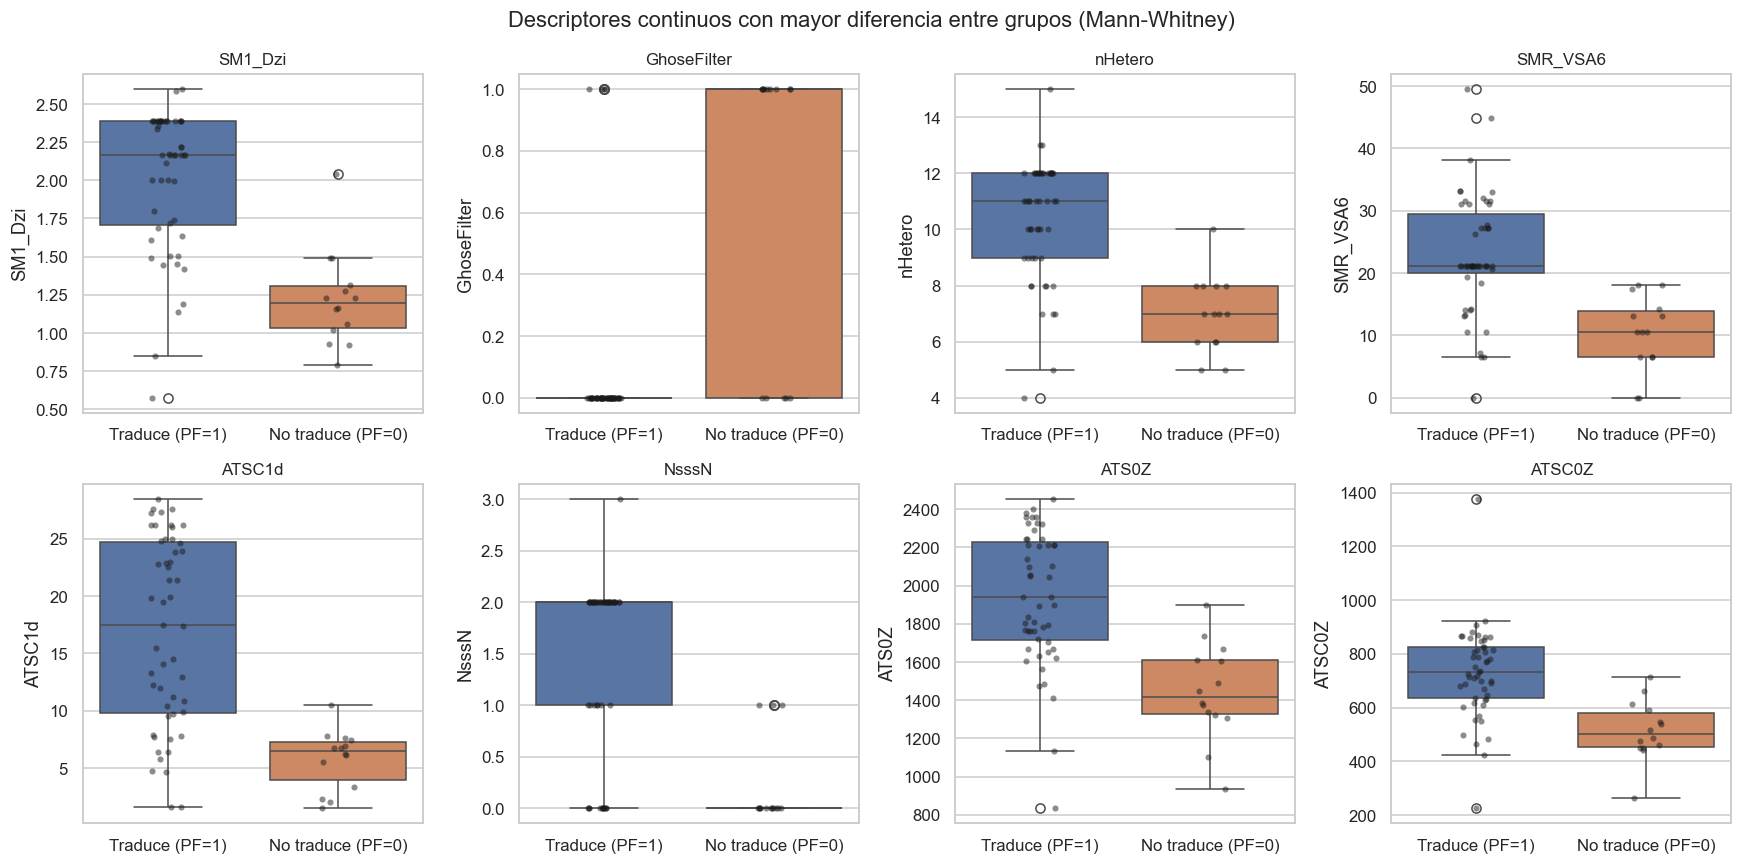

In [12]:
def plot_top_boxplots(continuous_clean, labels, uni_results, outdir, n_top=8):
    top = uni_results.head(n_top)["descriptor"].tolist()
    fig, axes = plt.subplots(2, (n_top + 1) // 2, figsize=(4 * ((n_top + 1) // 2), 8))
    axes = axes.flatten()
    plot_df = continuous_clean[top].copy()
    plot_df["Grupo"] = labels.map({1: "Traduce (PF=1)", 0: "No traduce (PF=0)"}).values
    for i, col in enumerate(top):
        sns.boxplot(data=plot_df, x="Grupo", y=col, ax=axes[i],
                    palette={"Traduce (PF=1)": "#4C72B0", "No traduce (PF=0)": "#DD8452"})
        sns.stripplot(data=plot_df, x="Grupo", y=col, ax=axes[i], color="k", alpha=0.5, size=4)
        axes[i].set_title(col, fontsize=11)
        axes[i].set_xlabel("")
    for j in range(len(top), len(axes)):
        axes[j].axis("off")
    fig.suptitle("Descriptores continuos con mayor diferencia entre grupos (Mann-Whitney)")
    fig.tight_layout()
    fig.savefig(outdir / "boxplots_top_descriptores.png", dpi=150)
    plt.show()


plot_top_boxplots(continuous_clean, labels, uni_cont, OUTDIR)

### Volcano plot: tamaño de efecto vs significancia

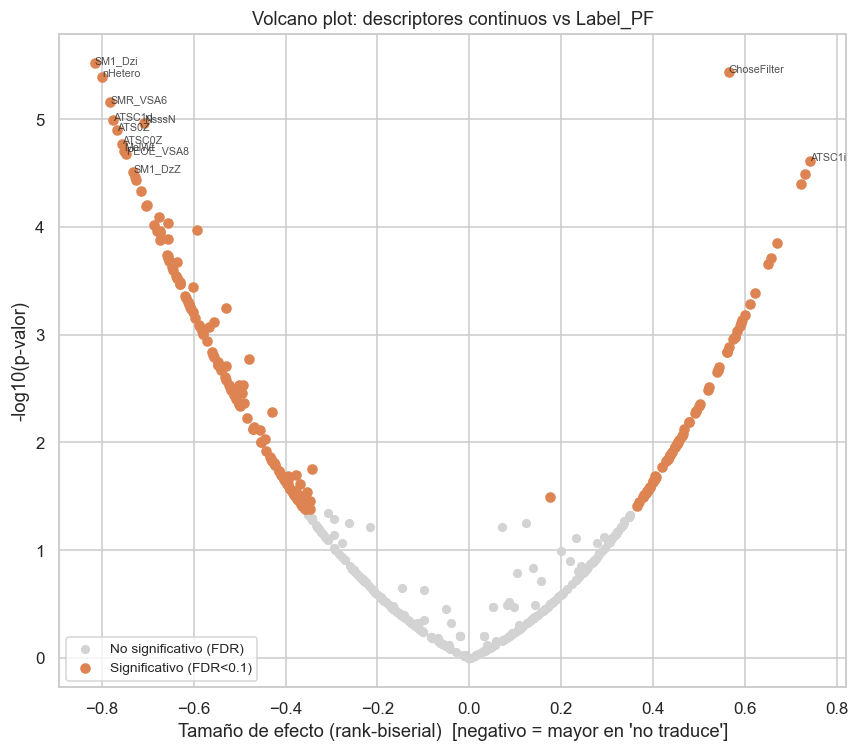

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
x = uni_cont["efecto_rank_biserial"]
y = -np.log10(uni_cont["p_valor"].clip(lower=1e-300))
sig = uni_cont["p_adj_fdr"] < FDR_ALPHA
ax.scatter(x[~sig], y[~sig], c="lightgray", s=25, label="No significativo (FDR)")
ax.scatter(x[sig], y[sig], c="#DD8452", s=35, label=f"Significativo (FDR<{FDR_ALPHA})")
for _, row in uni_cont[sig].head(12).iterrows():
    ax.annotate(row["descriptor"], (row["efecto_rank_biserial"], -np.log10(max(row["p_valor"], 1e-300))),
                fontsize=7, alpha=0.8)
ax.set_xlabel("Tamaño de efecto (rank-biserial)  [negativo = mayor en 'no traduce']")
ax.set_ylabel("-log10(p-valor)")
ax.set_title("Volcano plot: descriptores continuos vs Label_PF")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUTDIR / "volcano_plot.png", dpi=150)
plt.show()

## 7. Modelo Lasso + Leave-One-Out CV (triangulación, NO predicción)

Con n=65 (14 positivos en la clase minoritaria) **no tiene sentido** entrenar un modelo
con cientos de descriptores: memorizaría el ruido. Por eso:

1. Reducimos primero a los `top_k` descriptores más significativos en el test univariante.
2. Ajustamos una logística L1 con validación **Leave-One-Out**.
3. Reportamos qué descriptores tienen coeficiente ≠ 0 de forma consistente a través de
   los 65 folds → candidatos robustos.
4. El AUC/balanced accuracy se reporta **solo como referencia de que hay señal**, nunca
   como validación de un modelo desplegable (con este tamaño muestral sería autoengaño).

In [14]:
def robust_lasso_loocv(continuous_clean, labels, outdir, top_k_features=40):
    uni = univariate_continuous(continuous_clean, labels)
    top_feats = uni.sort_values("p_valor").head(top_k_features)["descriptor"].tolist()
    X_full = continuous_clean[top_feats].values
    y = labels.values

    scaler_full = StandardScaler()
    X_full_scaled = scaler_full.fit_transform(X_full)

    loo = LeaveOneOut()
    coefs = np.zeros((len(y), len(top_feats)))
    y_pred_proba = np.zeros(len(y))

    for train_idx, test_idx in loo.split(X_full_scaled):
        clf = LogisticRegression(penalty="l1", solver="liblinear", C=0.5,
                                  class_weight="balanced", random_state=RANDOM_STATE,
                                  max_iter=2000)
        clf.fit(X_full_scaled[train_idx], y[train_idx])
        coefs[test_idx[0], :] = clf.coef_[0]
        y_pred_proba[test_idx[0]] = clf.predict_proba(X_full_scaled[test_idx])[0, 1]

    auc = roc_auc_score(y, y_pred_proba)
    bal_acc = balanced_accuracy_score(y, (y_pred_proba >= 0.5).astype(int))
    print(f"Lasso LOO-CV: AUC={auc:.2f}, balanced_accuracy={bal_acc:.2f} "
          f"(señal, NO validación externa)")

    nonzero_frac = (coefs != 0).mean(axis=0)
    mean_coef = coefs.mean(axis=0)
    lasso_summary = pd.DataFrame({
        "descriptor": top_feats,
        "frac_folds_seleccionado": nonzero_frac,
        "coef_medio": mean_coef,
    }).sort_values("frac_folds_seleccionado", ascending=False)
    lasso_summary.to_csv(outdir / "lasso_loocv_summary.csv", index=False)

    robust_feats = lasso_summary[lasso_summary["frac_folds_seleccionado"] >= 0.8]
    print(f"{len(robust_feats)} descriptores seleccionados en >=80% de los folds LOO:")
    print(robust_feats["descriptor"].tolist())
    return lasso_summary, auc, bal_acc


lasso_summary, auc, bal_acc = robust_lasso_loocv(continuous_clean, labels, OUTDIR)
lasso_summary.head(15)

Lasso LOO-CV: AUC=0.90, balanced_accuracy=0.85 (señal, NO validación externa)
7 descriptores seleccionados en >=80% de los folds LOO:
['SM1_Dzi', 'GhoseFilter', 'IC2', 'PEOE_VSA8', 'ATSC2v', 'SMR_VSA6', 'SM1_DzZ']


,descriptor,frac_folds_seleccionado,coef_medio
0,SM1_Dzi,1.000000,0.620384
1,GhoseFilter,1.000000,-0.559525
31,IC2,1.000000,0.371980
9,PEOE_VSA8,0.984615,0.233128
14,ATSC2v,0.984615,0.745645
3,SMR_VSA6,0.969231,0.178963
11,SM1_DzZ,0.953846,0.122537
30,MAXssNH,0.215385,0.008797
18,AATSC2v,0.200000,0.040957
24,ATSC2Z,0.153846,0.021814


## 8. Chequeo de confusor: ¿es solo que los PF=0 son menos potentes en la enzima?

**Importante antes de sacar conclusiones.** Hay que descartar la explicación más simple:
que los compuestos `PF=0` son, dentro del grupo de activos en enzima, sencillamente
**menos potentes** en la propia enzima (mayor IC50/Ki) y por eso no alcanzan actividad
en el organismo completo — sin que la fisicoquímica tenga nada que ver.

In [15]:
def check_potency_confound(df, uni_cont, continuous_clean, outdir,
                            activity_col="activity_uM_FP2", top_n=15):
    if activity_col not in df.columns:
        return None

    g1 = df.loc[df[LABEL_COL] == 1, activity_col]
    g0 = df.loc[df[LABEL_COL] == 0, activity_col]
    u, p = mannwhitneyu(g1, g0, alternative="two-sided")

    print(f"Mediana IC50/Ki enzima (uM) - PF=1 (traduce):    {g1.median():.3f}")
    print(f"Mediana IC50/Ki enzima (uM) - PF=0 (no traduce): {g0.median():.3f}")
    print(f"Mann-Whitney U, p-valor = {p:.4f}")
    if p < 0.05:
        print("[!] Los PF=0 son significativamente MENOS potentes en la propia enzima.\n"
              "    Esto es un CONFUSOR real: parte de la señal fisicoquímica encontrada\n"
              "    podría reflejar 'compuestos peor optimizados en general' en lugar de\n"
              "    un problema específico de permeabilidad/traducción enzima->célula.")
    else:
        print("[OK] No hay diferencia significativa en potencia enzimática entre grupos.")

    top_desc = uni_cont.head(top_n)["descriptor"].tolist()
    rows = []
    for d in top_desc:
        r, pr = spearmanr(continuous_clean[d], df[activity_col])
        rows.append({"descriptor": d, "spearman_r_vs_potencia_enzima": r, "p_valor": pr})
    confound_df = pd.DataFrame(rows).sort_values("spearman_r_vs_potencia_enzima", key=abs, ascending=False)
    confound_df.to_csv(outdir / "chequeo_confusor_potencia.csv", index=False)
    return confound_df


confound_df = check_potency_confound(df, uni_cont, continuous_clean, OUTDIR)
confound_df

Mediana IC50/Ki enzima (uM) - PF=1 (traduce):    0.235
Mediana IC50/Ki enzima (uM) - PF=0 (no traduce): 3.325
Mann-Whitney U, p-valor = 0.0042
[!] Los PF=0 son significativamente MENOS potentes en la propia enzima.
    Esto es un CONFUSOR real: parte de la señal fisicoquímica encontrada
    podría reflejar 'compuestos peor optimizados en general' en lugar de
    un problema específico de permeabilidad/traducción enzima->célula.


,descriptor,spearman_r_vs_potencia_enzima,p_valor
10,ATSC1i,0.559597,0.000001
12,RPCG,0.443939,0.000212
5,NsssN,-0.434836,0.000295
2,nHetero,-0.418918,0.000514
8,MolWt,-0.396087,0.001090
0,SM1_Dzi,-0.392094,0.001237
4,ATSC1d,-0.376847,0.001973
13,GGI4,-0.333290,0.006668
3,SMR_VSA6,-0.307600,0.012682
6,ATS0Z,-0.241824,0.052291


## 9. Síntesis final: cruzar las 3 fuentes de evidencia

Solo se consideran "candidatos robustos" los descriptores respaldados por **al menos 2**
de: (a) significancia univariante FDR, (b) top loadings del PC discriminante, (c)
selección consistente en el Lasso LOO-CV.

In [16]:
def synthesize(uni_cont, top_loadings, lasso_summary, outdir, fdr_alpha=FDR_ALPHA):
    sig_univariate = set(uni_cont[uni_cont["p_adj_fdr"] < fdr_alpha]["descriptor"])
    top_pca = set(top_loadings.index[:20])
    robust_lasso = set(lasso_summary[lasso_summary["frac_folds_seleccionado"] >= 0.8]["descriptor"])

    rows = []
    for feat in sorted(sig_univariate | top_pca | robust_lasso):
        rows.append({
            "descriptor": feat,
            "significativo_univariante_FDR": feat in sig_univariate,
            "en_top_loadings_PCA": feat in top_pca,
            "robusto_en_lasso_LOOCV": feat in robust_lasso,
            "n_fuentes_que_coinciden": sum([feat in sig_univariate, feat in top_pca, feat in robust_lasso]),
        })
    summary = pd.DataFrame(rows).sort_values("n_fuentes_que_coinciden", ascending=False)
    summary.to_csv(outdir / "sintesis_descriptores_consenso.csv", index=False)
    return summary


summary = synthesize(uni_cont, top_loadings, lasso_summary, OUTDIR)
consenso = summary[summary["n_fuentes_que_coinciden"] >= 2]
print(f"{len(consenso)} descriptores respaldados por >=2 técnicas:")
consenso

16 descriptores respaldados por >=2 técnicas:


,descriptor,significativo_univariante_FDR,en_top_loadings_PCA,robusto_en_lasso_LOOCV,n_fuentes_que_coinciden
192,SpDiam_A,True,True,False,2
108,AXp-3d,True,True,False,2
181,SM1_DzZ,True,False,True,2
19,AATS5s,True,True,False,2
84,ATSC2p,True,True,False,2
185,SMR_VSA6,True,False,True,2
138,GhoseFilter,True,False,True,2
139,IC2,True,False,True,2
176,PEOE_VSA8,True,False,True,2
182,SM1_Dzi,True,False,True,2


## Conclusión

Revisa (en orden de fiabilidad):
1. `sintesis_descriptores_consenso.csv` — descriptores que aparecen en ≥2 técnicas.
2. `chequeo_confusor_potencia.csv` — descarta los descriptores que solo son proxies de
   la potencia enzimática (correlación alta con `activity_uM_FP2`); quédate con los que
   NO correlacionan fuerte con potencia pero SÍ con `Label_PF` — esos son los candidatos
   más limpios para "problema de traducción enzima→fenotipo" en sí.
3. Los boxplots y el volcano plot para comunicar visualmente el hallazgo.

Recuerda: con n=65 todo esto es **generador de hipótesis**, no una prueba causal. La
validación real vendría de sintetizar/testar unos pocos compuestos que varíen
específicamente en los descriptores de consenso, manteniendo la potencia enzimática
constante.